1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


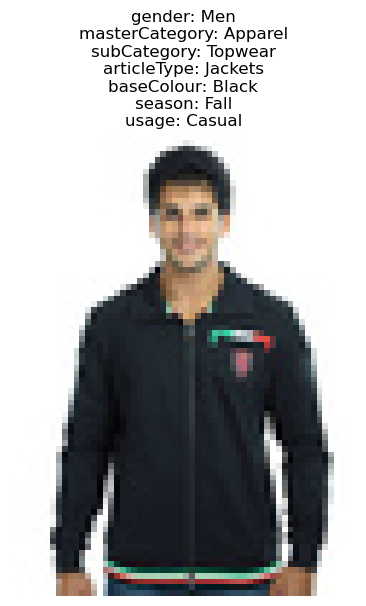

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step


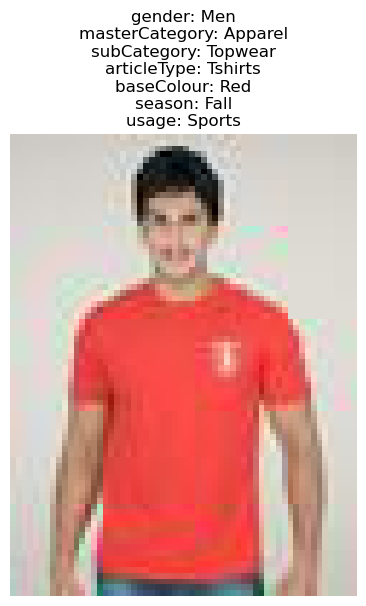

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step


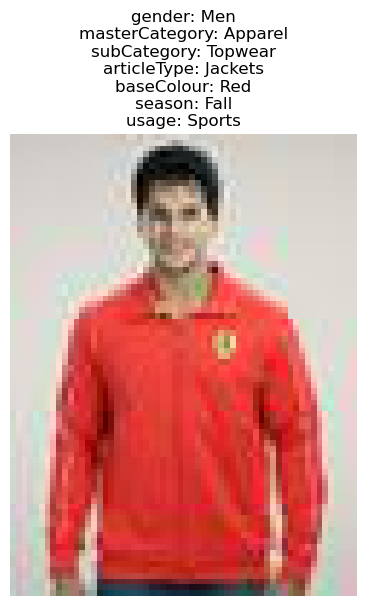

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step


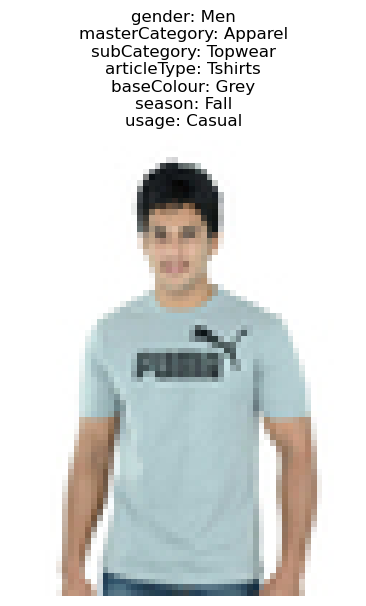

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step


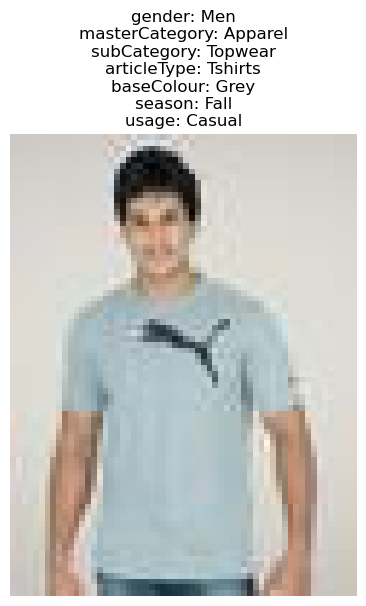

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step


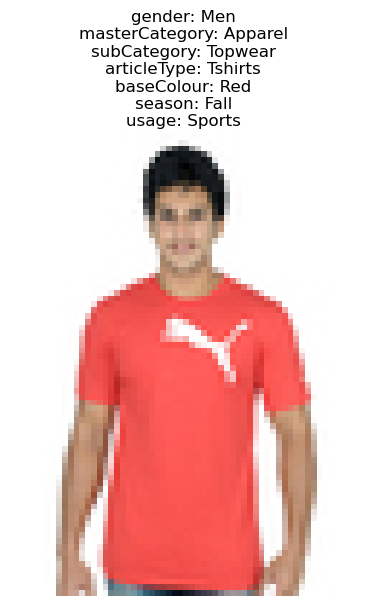

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step


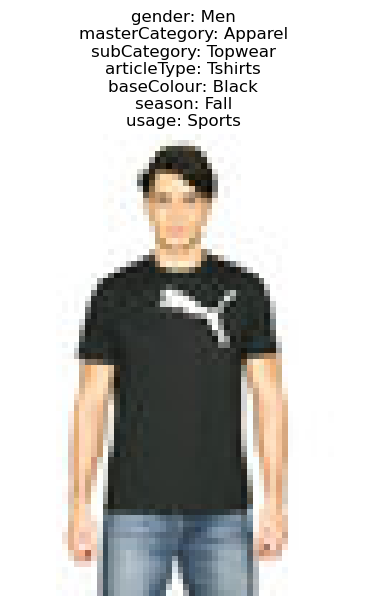

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step


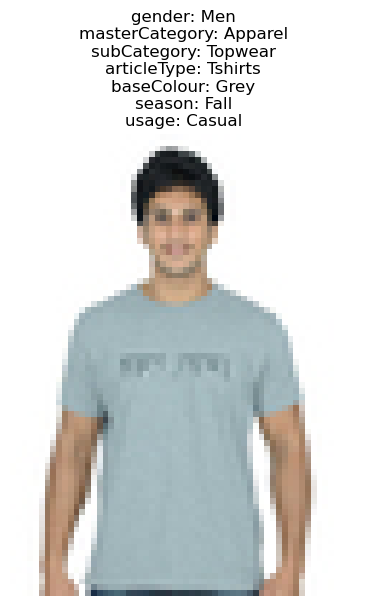

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step


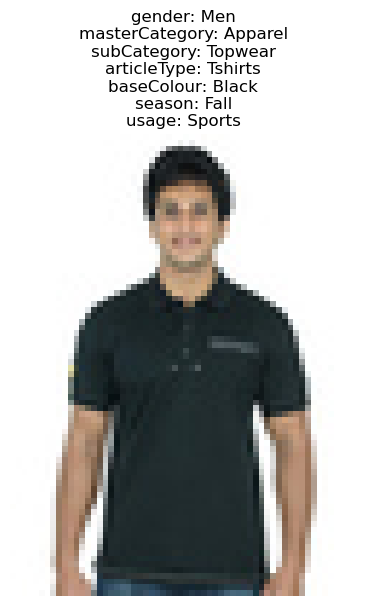

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step


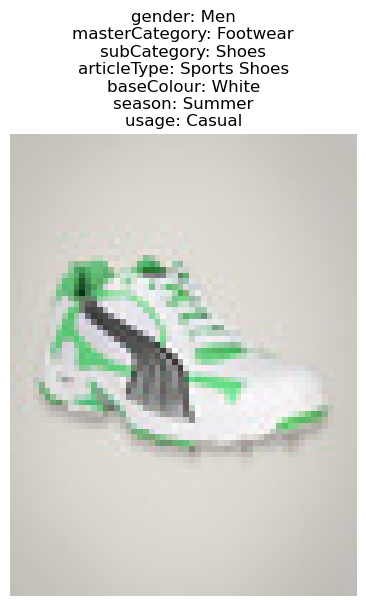

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step


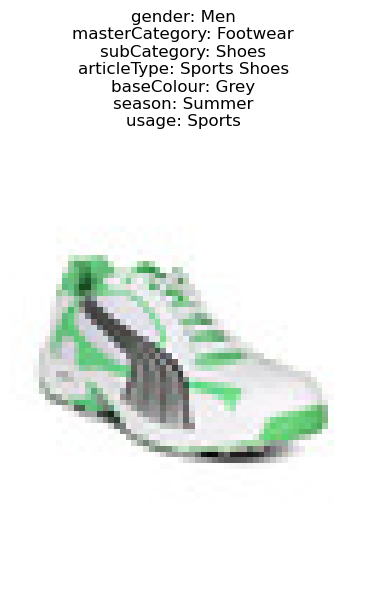

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step


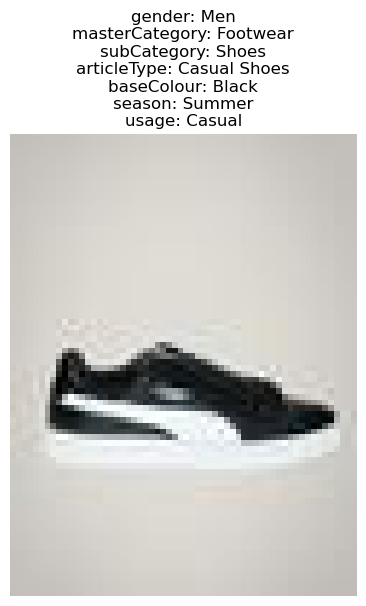

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step


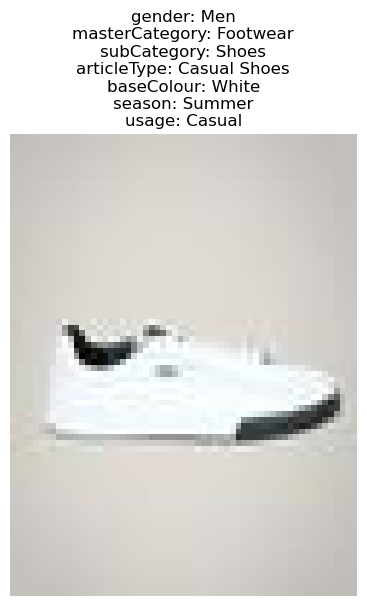

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step


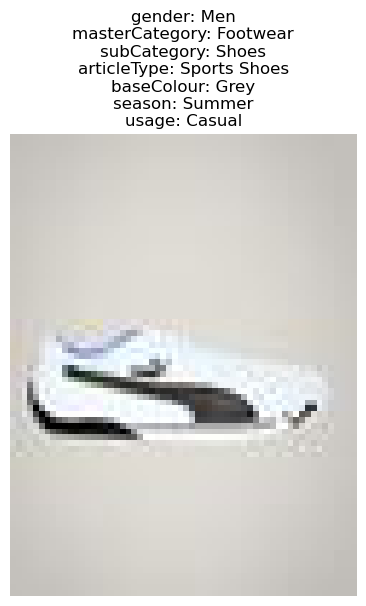

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step


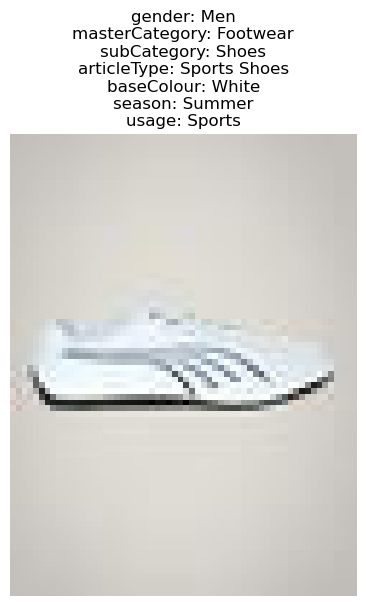

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step


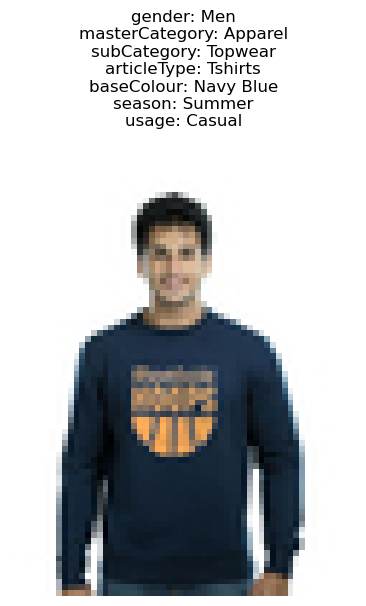

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step


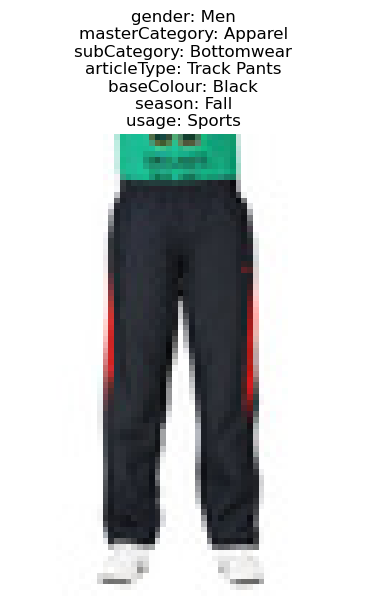

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step


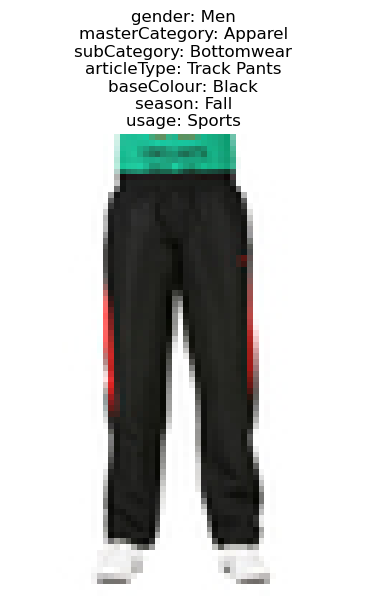

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step


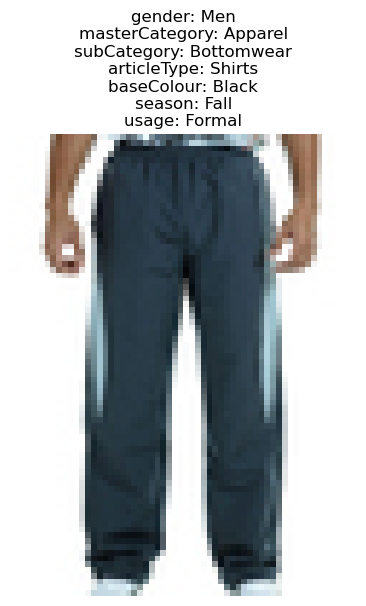

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step


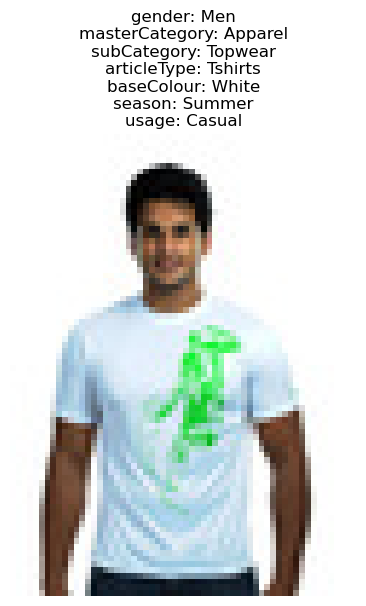

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step


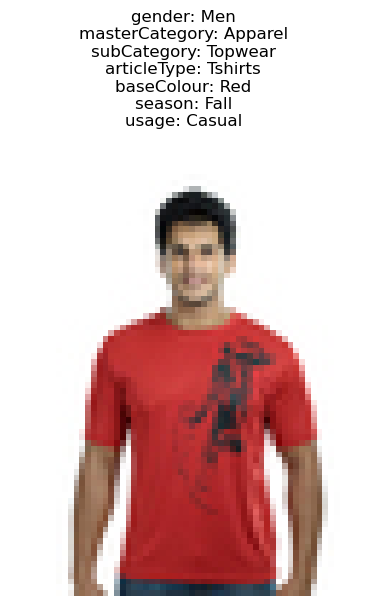

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step


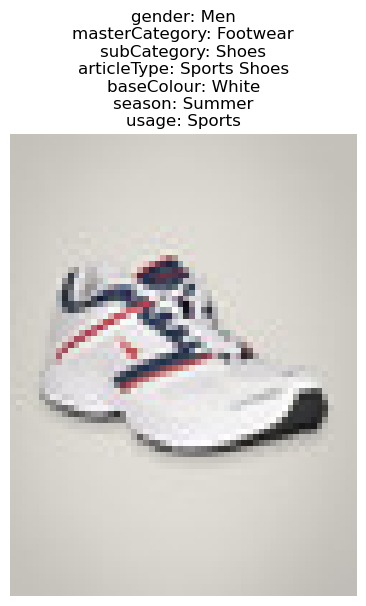

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step


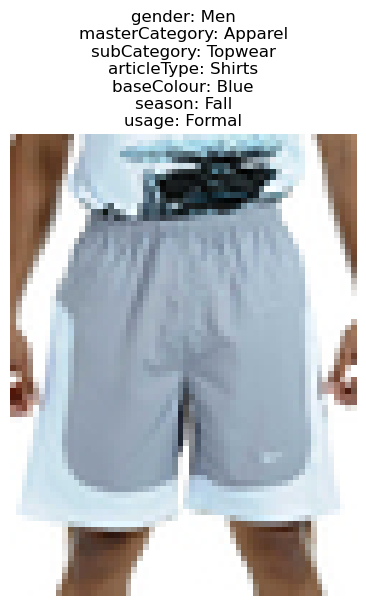

In [1]:
import tensorflow as tf
import numpy as np
import os
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array

model = tf.keras.models.load_model("best_model_v5_train_new_dataset.keras") 

image_dir = "images" #...........................................................

# Define class names
class_names = {
    'articleType': ['Ankle Pants', 'Backpacks', 'Belts', 'Blazers', 'Bracelet', 
                    'Bracelets', 'Caps', 'Casual Shoes', 'Churidar', 'Clutches', 
                    'Dresses', 'Duffel Bag', 'Earrings', 'Flats', 'Flip Flops', 
                    'Formal Shoes', 'Handbags', 'Heels', 'Jackets', 'Jeans', 
                    'Jeggings', 'Jewellery Set', 'Jumpsuit', 'Kaftan', 
                    'Laptop Bag', 'Leggings', 'Messenger Bag', 'Necklaces', 
                    'Palazzo', 'Pendant', 'Ring', 'Rompers', 'Sandals', 
                    'Scarves', 'Shirts', 'Shorts', 'Skirts', 'Socks', 
                    'Sports Shoes', 'Stockings', 'Sunglasses', 'Sweaters', 
                    'Sweatshirts', 'Swimwear', 'Ties', 'Tops', 'Track Pants', 
                    'Tracksuits', 'Trousers', 'Tshirts', 'Tunics', 'Waist Pouch', 
                    'Waistcoat', 'Watches'],
    'baseColour': ['Beige', 'Black', 'Blue', 'Brown', 'Green', 'Grey', 
                   'Khaki', 'Light Green', 'Metallic', 'Multi', 'Navy Blue', 
                   'Off White', 'Orange', 'Pink', 'Purple', 'Red', 'Rust', 
                   'Silver', 'Skin', 'Turquoise', 'White', 'Yellow'],
    'gender': ['Boys', 'Girls', 'Men', 'Unisex', 'Women'],
    'masterCategory': ['Accessories', 'Apparel', 'Footwear'],
    'season': ['Fall', 'Spring', 'Summer', 'Winter'],
    'subCategory': ['Bags', 'Belts', 'Bottomwear', 'Dress', 'Eyewear', 'Flip Flops', 
                    'Headwear', 'Jewellery', 'Sandal', 'Scarves', 'Shoes', 
                    'Socks', 'Ties', 'Topwear', 'Watches'],
    'usage': ['Casual', 'Formal', 'Local', 'Party', 'Sports']
}

# Define a function to preprocess images
def preprocess_image(image_path, target_size=(224, 224)):
    img = load_img(image_path, target_size=target_size)
    img_array = img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)  
    img_array = img_array / 255.0  
    return img_array

# Define a function to decode predictions
def decode_predictions(predictions):
    decoded = {}
    for i, category in enumerate(class_names.keys()):
        class_idx = np.argmax(predictions[i])  
        decoded[category] = class_names[category][class_idx]
    return decoded



# Make predictions and display each image with its labels
for filename in os.listdir(image_dir):
    if filename.endswith(".jpg") or filename.endswith(".png"):  
        image_path = os.path.join(image_dir, filename)
        
        # Preprocess the image
        img_array = preprocess_image(image_path)
        
        # Make prediction
        predictions = model.predict(img_array)
        
        # Decode predictions
        decoded = decode_predictions(predictions)
        
        # Load the image for display
        img = load_img(image_path)
        
        # Display the image and predictions
        plt.figure(figsize=(6, 6))
        plt.imshow(img)
        plt.axis('off')
        
        # Construct prediction text
        prediction_text = "\n".join([f"{key}: {value}" for key, value in decoded.items()])
        plt.title(prediction_text, fontsize=12, loc='center')
        
        plt.show()
